# Cardio Analysis

In [1]:

import numpy as np
import seaborn as sns
import pandas as pd
import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from models.mlp import BlackBoxModel
from models.lr import LogisticRegression
from models.svm import LinearSVM
from models.rbf import RBFNet

pd.set_option('display.max_columns', None)

%reload_ext autoreload
%autoreload 0

## Read and Process Data

In [2]:

df_ = pd.read_csv('data/cardio/cardio.csv', sep=';')
df = df_.drop(columns=['id'], axis=1).copy()

In [3]:
target_name = 'cardio'
target = df[target_name].replace({})

In [4]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Model Training

In [5]:
import os
# True 表示重新训练模型 False 表示加载已有模型
RETRAIN_MODEL = False  
REGENERATE_Y_TARGET = False
REGENERATE_X_INIT = False

X_INIT_PATH = "saved_models/cardio_X_init.pt"
MODEL_PATH = "saved_models/cardio_blackbox_model.pth"
FACTUAL_PATH = "saved_models/cardio_factual_sample.pt"
Y_TARGET_PATH = "saved_models/cardio_y_target.pt"
# 创建保存目录
os.makedirs("saved_models", exist_ok=True)

In [6]:
features = [
    'age', 
    'gender', 
    'height', 
    'weight', 
    'ap_hi', 
    'ap_lo', 
    'cholesterol',
    'gluc', 
    'smoke', 
    'alco', 
    'active'
]

df_X = df[features].copy()
df_y = df[target_name].copy()

In [7]:
seed = 42

np.random.seed(seed)  # for reproducibility


# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=seed)

std = X_train.std()
mean = X_train.mean()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# X_train, X_test, y_train, y_test = X_train.values, X_test.values, y_train.values, y_test.values

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

# Initialize the model, loss function, and optimizer
# model = LinearSVM(input_dim=X_train.shape[1])
# model = LogisticRegression(input_dim=X_train.shape[1])
model = BlackBoxModel(input_dim=X_train.shape[1])
# model = RBFNet(input_dim=X_train.shape[1], hidden_dim=X_train.shape[1], output_dim=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


# 训练或加载模型
if RETRAIN_MODEL:
    print("🔁 Training model from scratch...")

    num_epochs = 300
    for epoch in range(num_epochs):
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 测试评估
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor)
        y_pred_tensor = (test_outputs > 0.5).float()
        correct = (y_pred_tensor == y_test_tensor).float().sum()
        accuracy = correct / y_test_tensor.shape[0]
        print(f"✅ Final Test Accuracy: {accuracy.item():.4f}")

    # 保存模型和解释样本
    torch.save(model.state_dict(), MODEL_PATH)
    sample_num = 50
    indice = (X_test.sample(sample_num, random_state=seed)).index
    df_explain = X_test.loc[indice]
    torch.save(df_explain, FACTUAL_PATH)
    print("✅ Saved model & factual sample.")

else:
    print("📦 Loading model and factual sample...")
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()
    df_explain = torch.load(FACTUAL_PATH)
    print("✅ Loaded model & factual sample.")
# # Training loop
# num_epochs = 300
# for epoch in range(num_epochs):
#     # Forward pass
#     outputs = model(X_train_tensor)
#     loss = criterion(outputs, y_train_tensor)
    
#     # Backward pass and optimization
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

# # Evaluate on test set
# model.eval()
# with torch.no_grad():
#     test_outputs = model(X_test_tensor)
#     test_loss = criterion(test_outputs, y_test_tensor)

#     # Convert outputs to binary using 0.5 as threshold
#     y_pred_tensor = (test_outputs > 0.5).float()
#     correct_predictions = (y_pred_tensor == y_test_tensor).float().sum()
#     accuracy = correct_predictions / y_test_tensor.shape[0]

# accuracy.item()

📦 Loading model and factual sample...
✅ Loaded model & factual sample.


## Counterfactual Explanation

📦 Loaded y_target.


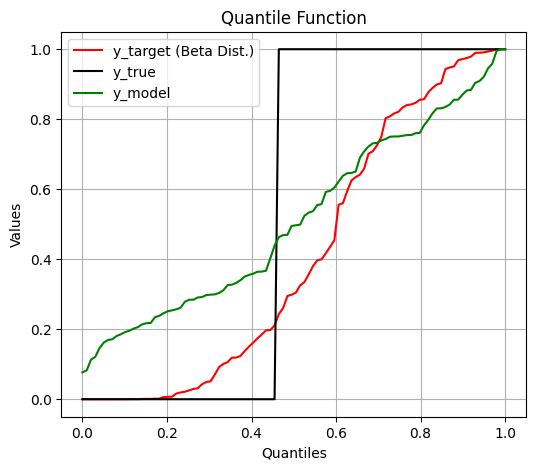

In [8]:
sample_num = 100
delta=0.15
alpha=0.1
N=10
explain_columns = [
    'age', 
    'gender', 
    'height', 
    'weight', 
    'ap_hi', 
    'ap_lo', 
    'cholesterol',
    'gluc', 
    'smoke', 
    'alco', 
    'active'
]

indice = (X_test.sample(sample_num)).index

df_explain = X_test.loc[indice]

# X = X_test.loc[indice].values
y = model(torch.FloatTensor(df_explain.values))

# 加载或生成 y_target
if REGENERATE_Y_TARGET:
    sample_num = df_explain.shape[0]
    y_target = torch.distributions.beta.Beta(0.2, 0.3).sample((sample_num,))
    torch.save(y_target, Y_TARGET_PATH)
    print("✅ Regenerated and saved y_target.")
else:
    y_target = torch.load(Y_TARGET_PATH)
    print("📦 Loaded y_target.")


if REGENERATE_X_INIT:
    noise = torch.randn_like(torch.FloatTensor(df_explain.values)[:, [df_explain.columns.get_loc(c) for c in explain_columns]]) * 0.01
    X_init = torch.FloatTensor(df_explain.values).clone()
    X_init[:, [df_explain.columns.get_loc(c) for c in explain_columns]] += noise
    torch.save(X_init, X_INIT_PATH)
else:
    X_init = torch.load(X_INIT_PATH)
# y_target = torch.round(torch.distributions.beta.Beta(0.2, 0.3).sample((sample_num,)))
# y_target = torch.ones_like(y)
y_true = y_test.loc[indice]

# Sort the arrays
y_target_sorted = np.sort(y_target.numpy())
y_true_sorted = np.sort(y_true)
y_sorted = np.sort(y.squeeze().detach().numpy())

# Generate quantiles
quantiles = np.linspace(0, 1, sample_num)

# Plotting
plt.figure(figsize=(6, 5))
plt.plot(quantiles, y_target_sorted, label='y_target (Beta Dist.)', color='red')
plt.plot(quantiles, y_true_sorted, label='y_true', color='black')
plt.plot(quantiles, y_sorted, label='y_model', color='green')


plt.title('Quantile Function')
plt.xlabel('Quantiles')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
category = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
continuous = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cardio']

categorical_columns = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
continuous_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

In [10]:
import os
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
output_dir = f"training_plots_cardio/Result_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

def optimization_callback(iteration):

    X_factual_standardized = explainer.X_prime.detach().numpy()
    X_counterfactual_standardized = explainer.X.detach().numpy()

    X_factual_original = X_factual_standardized * std.values + mean.values
    X_counterfactual_original = X_counterfactual_standardized * std.values + mean.values

    df_factual = pd.DataFrame(X_factual_original, columns=explain_columns)
    df_counterfactual = pd.DataFrame(X_counterfactual_original, columns=explain_columns)

    y_factual = explainer.model(explainer.X_prime).detach().numpy()
    y_counterfactual = explainer.model(explainer.X).detach().numpy()


    dtype_dict = df.dtypes.apply(lambda x: x.name).to_dict()

    def recovering_types(df_to_recover, dtype_dict):
        for k, v in dtype_dict.items():
            if k in df_to_recover.columns:
                if v.startswith('int'):  
                    df_to_recover[k] = df_to_recover[k].round().astype(v)
                else: 
                    df_to_recover[k] = df_to_recover[k].astype(v)
        return df_to_recover


    df_factual = recovering_types(df_factual, dtype_dict)
    df_counterfactual = recovering_types(df_counterfactual, dtype_dict)

 
    df_factual['cardio'] = y_target_sorted
    df_counterfactual['cardio'] = y_counterfactual


    quantiles_factual = np.linspace(0, 1, len(df_factual))
    quantiles_counterfactual = np.linspace(0, 1, len(df_counterfactual))


    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 24))  # ✅ 调整图表大小，避免重叠


    for i, feature in enumerate(explain_columns+ ['cardio']):
        row, col = divmod(i, 3) 
        factual_values = df_factual[feature]
        counterfactual_values = df_counterfactual[feature]

        if feature in category:
            bins = np.arange(factual_values.min(), factual_values.max() + 2)
            width = 0.35  

            axes[row, col].bar(bins[:-1] - width / 2, np.histogram(factual_values, bins=bins)[0], 
                               width=width, alpha=0.7, label='Fact.', color='blue', edgecolor='black')
            axes[row, col].bar(bins[:-1] + width / 2, np.histogram(counterfactual_values, bins=bins)[0], 
                               width=width, alpha=0.7, label='C.Fact.', color='red', edgecolor='black')
        elif feature == "cardio":  

            factual_sorted = np.sort(factual_values)
            counterfactual_sorted = np.sort(counterfactual_values)

            axes[row, col].plot(quantiles_factual, factual_sorted, label="target", color='green')
            axes[row, col].plot(quantiles_factual, y_true_sorted, label="Factual", color='blue')
            axes[row, col].plot(quantiles_counterfactual, counterfactual_sorted, label="Counterfactual", color='red') 

            axes[row, col].set_xlabel("Cardio") 
            axes[row, col].set_ylabel("Quantiles")   
        else:
            factual_sorted = np.sort(factual_values)
            counterfactual_sorted = np.sort(counterfactual_values)

            axes[row, col].plot(factual_sorted, quantiles_factual, label="Factual", color='blue')
            axes[row, col].plot(counterfactual_sorted, quantiles_counterfactual, label="Counterfactual", color='red')

        axes[row, col].set_title(feature.capitalize())
        axes[row, col].set_xlabel(feature)
        axes[row, col].set_ylabel("Quantiles")
        axes[row, col].legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    fig.suptitle(f'Iteration = {iteration}', fontsize=36)

    filename = os.path.join(output_dir, f'iteration_{iteration}.png')
    plt.savefig(filename)
    plt.close() 

In [11]:
# # Original

# import os
# from datetime import datetime
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# from explainers.dce import DistributionalCounterfactualExplainer

# explainer = DistributionalCounterfactualExplainer(
#     model=model, 
#     df_X=df_explain, 
#     explain_columns=explain_columns,
#     categorical_columns=categorical_columns,
#     continuous_columns=continuous_columns,
#     y_target=y_target,
#     X_init=X_init, 
#     lr=1e-1, 
#     n_proj=10,
#     delta=delta)

# explainer.optimize(U_1=0.1, U_2=0.25, l=0, r=1, max_iter=100, tau=1e1, kappa=0.02, bootstrap=True, callback=optimization_callback)

In [ ]:
# # Monte Carlo Sampling

# import os
# from datetime import datetime
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# from explainers.dce_mc import DistributionalCounterfactualExplainer

# explainer = DistributionalCounterfactualExplainer(
#     model=model, 
#     df_X=df_explain, 
#     explain_columns=explain_columns,
#     categorical_columns=categorical_columns,
#     continuous_columns=continuous_columns,
#     y_target=y_target,
#     X_init=X_init, 
#     lr=1e-1, 
#     n_proj=10,
#     delta=delta)

# explainer.optimize_mc_sampling(
#     U_1=0.1, 
#     U_2=0.25, 
#     l=0, 
#     r=1, 
#     max_iter=100, 
#     num=10, 
#     kappa=0.02, 
#     bootstrap=True, 
#     callback=optimization_callback
# )

In [13]:
# Genetic

import os
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from explainers.dce_genetic import DistributionalCounterfactualExplainer

explainer = DistributionalCounterfactualExplainer(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    categorical_columns=categorical_columns,
    continuous_columns=continuous_columns,
    y_target=y_target,
    X_init=X_init, 
    lr=1e-1, 
    n_proj=10,
    delta=delta)

explainer.optimize_genetic(
    U_1=0.5, 
    U_2=0.5, 
    l=0.2, 
    r=1, 
    max_iter=100, 
    num=10, 
    kappa=0.02, 
    bootstrap=True, 
    callback=optimization_callback,
    top_k=50
)

INFO:root:Random sampling
INFO:root:Iteration 0: 
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.24492867533254165
INFO:root:eta=0.7369641594498118, l=0.21600000000000003, r=1, best_gap=inf
INFO:root:Iter 1: Q = 0.022638892754912376, term1 = 7.47313242754899e-05, term2 = 0.0306924507021904
INFO:root:Iteration 1: 
INFO:root:U_1-Qu_upper=0.2463637027348483, U_2-Qv_upper=0.22272550362891835
INFO:root:eta=0.6277535435132968, l=0.23168000000000002, r=1, best_gap=0.7449286753325417
INFO:root:Iter 2: Q = 0.02966693416237831, term1 = 0.025599908083677292, term2 = 0.03207860514521599
INFO:root:Iteration 2: 
INFO:root:U_1-Qu_upper=0.22069943396966496, U_2-Qv_upper=0.1547019802406624
INFO:root:eta=0.6833772570928268, l=0.24704640000000003, r=1, best_gap=0.46908920636376666
INFO:root:Iter 3: Q = 0.04222764074802399, term1 = 0.030941244214773178, term2 = 0.04745686054229736
INFO:root:Iteration 3: 
INFO:root:U_1-Qu_upper=0.20509239548253527, U_2-Qv_upper=0.14185545530900168
INFO:root:eta=0.6921422758179

KeyboardInterrupt: 

In [ ]:
# import os 
# import pickle 
# dump_data_path = './data/cardio/'
# with open(os.path.join(dump_data_path, "explainer_convergence.pkl"), "wb") as file:
#     pickle.dump(explainer, file)

In [ ]:
# import os 
# import pickle 
# dump_data_path = './data/cardio/'
# with open(os.path.join(dump_data_path, "explainer_convergence.pkl"), 'rb') as file:
#     explainer = pickle.load(file)

In [ ]:
#SWD上界
s_qu = ""
s_u1 = ""

points_qu = list(map(lambda x: x.item(), explainer.swd_upper_list))
# points_list = list(map(lambda x: x.item(), explainer.swd_upper_list))[:iteration]
# points_list = list(map(lambda x: x.item() if type(x)==torch.Tensor else x, explainer.eta_list))
# points_list = explainer.interval_right_list

for i, v in enumerate(points_qu):
    s_qu += f"({i},{v})"
    s_u1 += f"({i},0.1)"
print("Qu, U1")
print(s_qu)
print(s_u1)

Qu, U1
(0,0.0)(1,0.0)(2,0.0)(3,0.0)(4,0.0)(5,0.0)(6,0.0)(7,0.0)(8,0.0)(9,0.0)(10,0.0)(11,0.0)(12,0.0)(13,0.0)(14,0.0)(15,0.0)(16,0.0)(17,0.0)(18,0.0)(19,0.0)(20,0.0)(21,0.0)(22,0.0)(23,0.0)(24,0.0)(25,0.0)(26,0.0)(27,0.0)(28,0.0)(29,0.0)(30,0.0)(31,0.0)(32,0.0)(33,0.0)(34,0.0)(35,0.0)(36,0.0)(37,0.0)(38,0.0)(39,0.0)(40,0.0)(41,0.0)(42,0.0)(43,0.0)(44,0.0)(45,0.0)(46,0.0)(47,0.0)(48,0.0)(49,0.0)(50,0.0)(51,0.0)(52,0.0)(53,0.0)(54,0.0)(55,0.0)(56,0.0)(57,0.0)(58,0.0)(59,0.0)(60,0.0)(61,0.0)(62,0.0)(63,0.0)(64,0.0)(65,0.0)(66,0.0)(67,0.0)(68,0.0)(69,0.0)(70,0.0)(71,0.0)(72,0.0)(73,0.0)(74,0.0)(75,0.0)(76,0.0)(77,0.0)(78,0.0)(79,0.0)(80,0.0)(81,0.0)(82,0.0)(83,0.0)(84,0.0)(85,0.0)(86,0.0)(87,0.0)(88,0.0)(89,0.0)(90,0.0)(91,0.0)(92,0.0026139436798651257)(93,0.0)(94,0.0)(95,0.0)(96,0.0)(97,0.0)(98,0.0)(99,0.0)
(0,0.1)(1,0.1)(2,0.1)(3,0.1)(4,0.1)(5,0.1)(6,0.1)(7,0.1)(8,0.1)(9,0.1)(10,0.1)(11,0.1)(12,0.1)(13,0.1)(14,0.1)(15,0.1)(16,0.1)(17,0.1)(18,0.1)(19,0.1)(20,0.1)(21,0.1)(22,0.1)(23,0.1)(2

In [ ]:
#WD上界
s_qv = ""
s_u2 = ""

points_qv = list(map(lambda x: x.item(), explainer.wd_upper_list))

for i, v in enumerate(points_qv):
    s_qv += f"({i},{v})"
    s_u2 += f"({i},0.25)"
print("Qv, U2")
print(s_qv)
print(s_u2)

Qv, U2
(0,0.25507132466745835)(1,0.2457418449925801)(2,0.23467632989993745)(3,0.2320410689249568)(4,0.22677399920897562)(5,0.22272823711385778)(6,0.21195141050072056)(7,0.21236550674870433)(8,0.21172772512556223)(9,0.20336534455363997)(10,0.2015609442896651)(11,0.20342665468104945)(12,0.19303353947130814)(13,0.19583470057879335)(14,0.1971780909707491)(15,0.19654383790522356)(16,0.18994482436941312)(17,0.1913640639954823)(18,0.18511316085015314)(19,0.18891003791016342)(20,0.19117873802793411)(21,0.17544605562275484)(22,0.1828040676332228)(23,0.18303201619940498)(24,0.18319220154493632)(25,0.17772412316392955)(26,0.18218355298623076)(27,0.18063897506406879)(28,0.18020481454623966)(29,0.1764633383947952)(30,0.18026504734720802)(31,0.18105039761223268)(32,0.1710799799292126)(33,0.17212356879577995)(34,0.1739229445276994)(35,0.17236746412826545)(36,0.16890606651739498)(37,0.17232751650866673)(38,0.17587219303044616)(39,0.16990788055483932)(40,0.16894912143503907)(41,0.1636815680356943)(42,0

In [ ]:
s_eta = ""
s_eta_r = ""
s_eta_l = ""
eta_points = list(map(lambda x: x.item() if type(x)==torch.Tensor else x, explainer.eta_list))
eta_r_points = explainer.interval_left_list
eta_l_points = explainer.interval_right_list

for i, v in enumerate(eta_points):
    s_eta += f"({i},{v})"

for i, v in enumerate(eta_r_points):
    s_eta_r += f"({i},{v})"

for i, v in enumerate(eta_l_points):
    s_eta_l += f"({i},{v})"

print("eta, (l,r)")
print(s_eta)
print(s_eta_r)
print(s_eta_l)

eta, (l,r)
(0,1)(1,0.9599744316694026)(2,0.8723865382420561)(3,0.8567060408030587)(4,0.8261493233874704)(5,0.8063080680336323)(6,0.7558464506387831)(7,0.762621536575145)(8,0.7645179680248607)(9,0.73484072030751)(10,0.7333704730009947)(11,0.7455694442599424)(12,0.7152096433959425)(13,0.7298073682451826)(14,0.7395085146751067)(15,0.7427208583202916)(16,0.7284199085724912)(17,0.7378163691283963)(18,0.7264479407012893)(19,0.7416569310137011)(20,0.7527437893790765)(21,0.7205600159067348)(22,0.7423139300159096)(23,0.7479807226841462)(24,0.7533752678525265)(25,0.7468250152868765)(26,0.7610106881180493)(27,0.7626407984279826)(28,0.7665304677054723)(29,0.764132085779291)(30,0.7758898648130091)(31,0.7818360749557702)(32,0.7689198339368657)(33,0.7752249351984658)(34,0.7826110315671251)(35,0.7845066334006783)(36,0.7836169742240435)(37,0.7929802312315788)(38,0.802437779906754)(39,0.7977390563072364)(40,0.8004737143320675)(41,0.7976436555550841)(42,0.8033329320702842)(43,0.8138948665660064)(44,0.818

In [ ]:
#参数 eta 及其相应的左右区间 (l, r)
which_X = explainer.best_X

factual_X = df[df_X.columns].loc[indice].copy()
counterfactual_X = pd.DataFrame(
    which_X.detach().numpy() * std[df_X.columns].values + mean[df_X.columns].values,
    columns=df_X.columns,
)

dtype_dict = df.dtypes.apply(lambda x: x.name).to_dict()
for k, v in dtype_dict.items():
    if k in counterfactual_X.columns:
        if v[:3] == "int":
            counterfactual_X[k] = counterfactual_X[k].round().astype(v)
        else:
            counterfactual_X[k] = counterfactual_X[k].astype(v)

factual_y = pd.DataFrame(
    y.detach().numpy(), columns=[target_name], index=factual_X.index
)
counterfactual_y = pd.DataFrame(
    explainer.y.detach().numpy(), columns=[target_name], index=factual_X.index
)

# Recover the type of counterfactual_X
dtype_dict = df.dtypes.apply(lambda x: x.name).to_dict()
for k, v in dtype_dict.items():
    if k in counterfactual_X.columns:
        if v[:3] == "int":
            counterfactual_X[k] = counterfactual_X[k].round().astype(v)
        else:
            counterfactual_X[k] = counterfactual_X[k].astype(v)

counterfactual_X.index = factual_X.index
counterfactual_X[target_name] = counterfactual_y
factual_X[target_name] = factual_y

In [ ]:
pd.DataFrame({
    'factual_y': factual_y[target_name].values,
    'counterfactual_y': counterfactual_y[target_name].values,
})

,factual_y,counterfactual_y
0,0.171323,0.157601
1,0.256929,0.165678
2,0.169301,0.152159
3,0.797914,0.827755
4,0.999960,0.999965
...,...,...
95,0.752720,0.837262
96,0.251563,0.206431
97,0.438602,0.319972
98,0.754700,0.784794


In [ ]:
import os
import pickle 

dump_data_path = './data/cardio/'

factual_X.to_csv(os.path.join(dump_data_path, "factual.csv"), index=False)
counterfactual_X.to_csv(
    os.path.join(dump_data_path, "counterfactual.csv"), index=False
)
with open(os.path.join(dump_data_path, "explainer.pkl"), "wb") as file:
    pickle.dump(explainer, file)

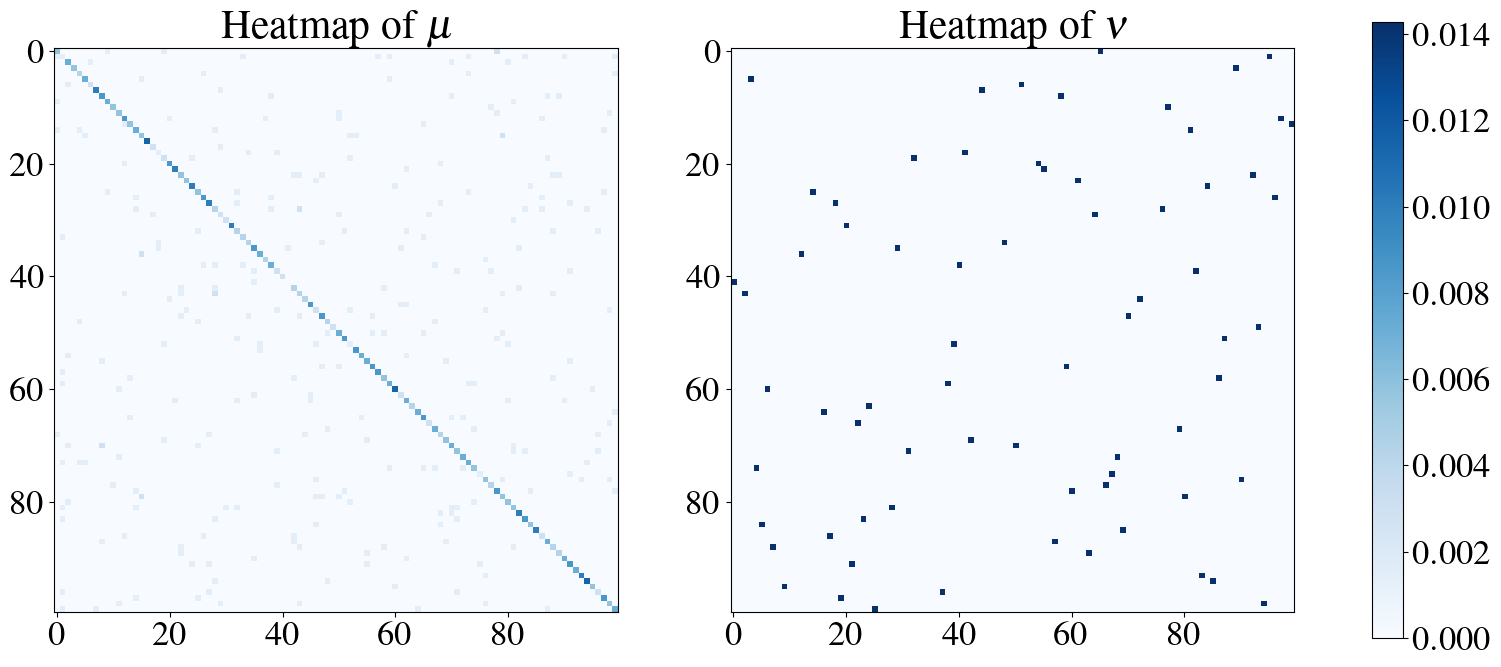

In [ ]:
import matplotlib.pyplot as plt

fontsize = 25

# Enable LaTeX text rendering in Matplotlib
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{times}",  # Ensure you use the times package
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman"],  # This should use Times font
    "font.size": fontsize
})

matrix_nu = explainer.wd.nu.detach().numpy()

mu_avg = torch.zeros_like(explainer.swd.mu_list[0])
for mu in explainer.swd.mu_list:
    mu_avg += mu

total_sum = mu_avg.sum()

matrix_mu = mu_avg / total_sum

# Determine the global minimum and maximum values across both matrices
vmin = min(matrix_mu.min(), matrix_nu.min())
vmax = max(matrix_mu.max(), matrix_nu.max())

# Create a figure and a set of subplots
fig, axs = plt.subplots(1, 2, figsize=(20, 8), facecolor='white')  # Set figure background to white

# Set the background of each axis to white
for ax in axs:
    ax.set_facecolor('white')

# First subplot for matrix_mu with 'Blues' color map
im_mu = axs[0].imshow(matrix_mu, cmap='Blues', vmin=vmin, vmax=vmax)
axs[0].set_title("Heatmap of $\mu$")

# Second subplot for matrix_nu with 'Blues' color map
im_nu = axs[1].imshow(matrix_nu, cmap='Blues', vmin=vmin, vmax=vmax)
axs[1].set_title("Heatmap of $\\nu$")

# Create a colorbar for the whole figure
fig.colorbar(im_mu, ax=axs, orientation='vertical')

plt.savefig('./pictures/transportation_plan.eps', format='eps', bbox_inches='tight')


# # Display the plots
plt.show()
plt.close(fig)

In [ ]:
row_num  = 20

# Interleave rows
combined = pd.concat([factual_X.head(row_num), counterfactual_X.head(row_num)]).sort_index(kind='merge')

# Define formatters for specific columns
formatters = {
    "cardio": lambda x: f"{x:.4f}",
    "weight": lambda x: f"{x:.1f}"
}


# Convert to LaTeX
latex_code = combined.to_latex(index=False, formatters=formatters, 
                               caption="[\\textit{{German-Credit}}] Data points of factual and counterfactual distributions.", label="tab:german-credit")

print(latex_code)

\begin{table}
\caption{[\textit{{German-Credit}}] Data points of factual and counterfactual distributions.}
\label{tab:german-credit}
\begin{tabular}{rrrrrrrrrrrr}
\toprule
age & gender & height & weight & ap_hi & ap_lo & cholesterol & gluc & smoke & alco & active & cardio \\
\midrule
17427 & 2 & 159 & 58.0 & 120 & 80 & 1 & 1 & 0 & 0 & 1 & 0.2139 \\
17396 & 2 & 159 & 58.1 & 120 & 82 & 1 & 1 & 0 & 0 & 1 & 0.1571 \\
20406 & 1 & 162 & 89.0 & 150 & 70 & 1 & 3 & 0 & 0 & 1 & 0.7507 \\
20382 & 1 & 162 & 88.9 & 153 & 70 & 1 & 3 & 0 & 0 & 1 & 0.8689 \\
17733 & 2 & 166 & 70.0 & 150 & 90 & 1 & 1 & 0 & 0 & 0 & 0.9453 \\
17745 & 2 & 166 & 70.0 & 151 & 92 & 1 & 1 & 0 & 0 & 0 & 0.9522 \\
18065 & 2 & 165 & 67.0 & 120 & 80 & 1 & 1 & 0 & 0 & 1 & 0.2569 \\
18060 & 2 & 165 & 67.2 & 119 & 80 & 1 & 1 & 0 & 0 & 1 & 0.1657 \\
21240 & 1 & 162 & 69.0 & 7 & 80 & 1 & 1 & 0 & 0 & 1 & 0.3643 \\
21254 & 1 & 162 & 69.0 & 8 & 81 & 1 & 1 & 0 & 0 & 1 & 0.3622 \\
18169 & 2 & 167 & 70.0 & 100 & 70 & 1 & 1 & 0 & 0 & 1 & 0.